<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


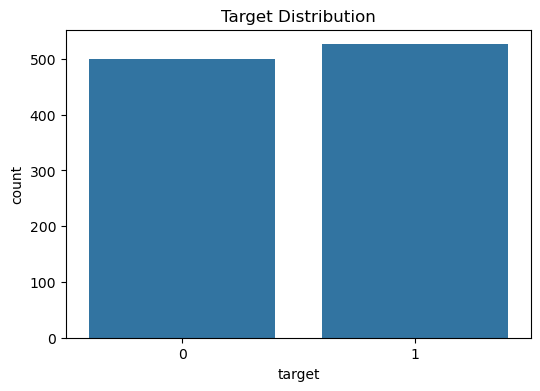

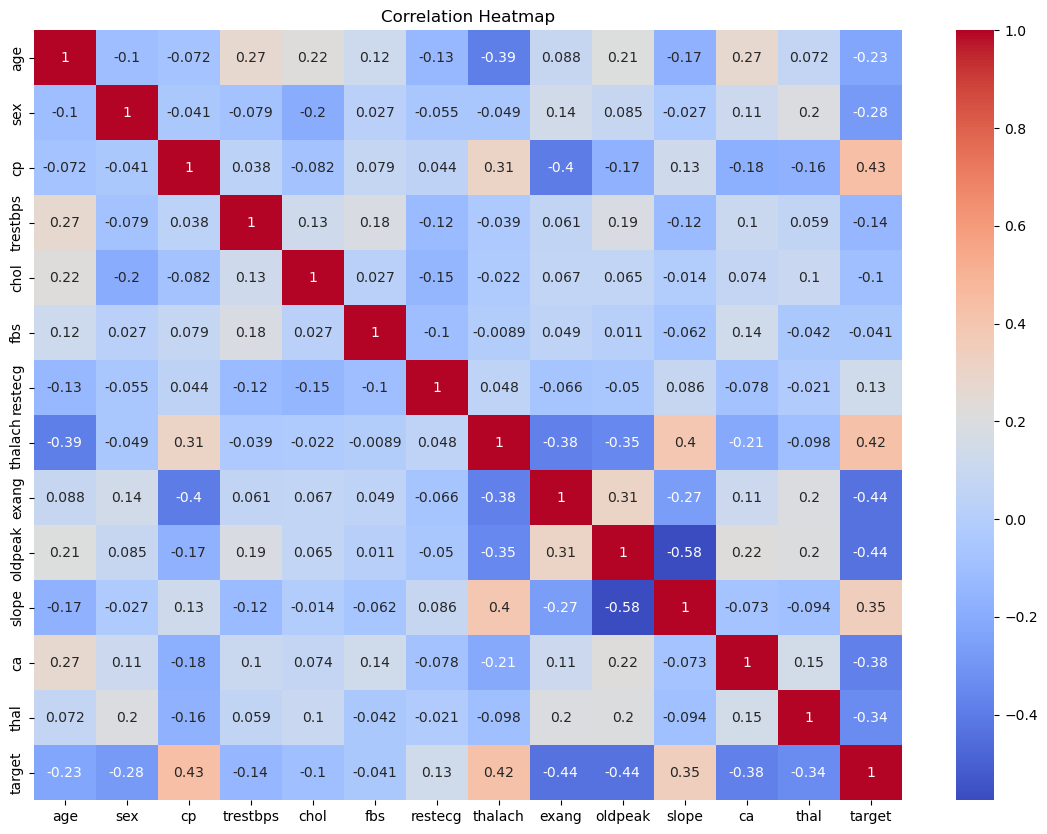

Accuracy : 0.8
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205



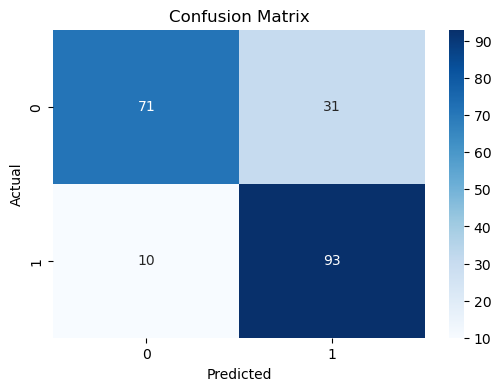

Model Saved Successfully


In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("../data/heart.csv")

# ==========================================
# DATASET HEAD
# ==========================================

df.head()

# ==========================================
# SHAPE
# ==========================================

df.shape

# ==========================================
# INFO
# ==========================================

df.info()

# ==========================================
# NULL VALUES
# ==========================================

df.isnull().sum()

# ==========================================
# DESCRIBE
# ==========================================

df.describe()

# ==========================================
# TARGET DISTRIBUTION
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Target Distribution")

plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop("target", axis=1)

y = df["target"]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

# ==========================================
# DECISION TREE CLASSIFIER
# ==========================================

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

# ==========================================
# TRAIN MODEL
# ==========================================

model.fit(
    x_train_scaled,
    y_train
)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = model.predict(
    x_test_scaled
)

# ==========================================
# ACCURACY
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# ==========================================
# SAVE MODEL
# ==========================================

joblib.dump(
    model,
    "../models/decision_tree_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("Model Saved Successfully")